# Data

We'll use the UCI Wine Dataset for this exercise 

[UCI Wine Data Set](http://archive.ics.uci.edu/ml/datasets/Wine)

In [1]:
!wget http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data -nc -O wine.data

--2018-11-08 00:52:33--  http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.249
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.249|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10782 (11K) [text/plain]
Saving to: ‘wine.data’

wine.data           100%[===================>]  10.53K  --.-KB/s    in 0s      

2018-11-08 00:52:33 (198 MB/s) - ‘wine.data’ saved [10782/10782]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('wine.data')

# Column names from: http://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.names
columns = ['vinyard','alcohol','malic acid','ash','ash alcalinity','magnesium',
           'Total phenols','Flavanoids','Nonflavanoid phenols','Proanthocyanins',
           'Color intensity','Hue','dilute OD280/OD315', 'Proline']

data.columns = columns

vinyard = data['vinyard']
data = data.drop(['vinyard'],axis=1)
data.head()

,alcohol,malic acid,ash,ash alcalinity,magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,dilute OD280/OD315,Proline
0,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


# PCA
Principal Components Analysis will give us a view into our data that maximizes its variance, potentially improving intuition and learning algorithms. Let's look at the below `data.std()` output.

In [3]:
print(data.std())

alcohol                   0.808808
malic acid                1.119314
ash                       0.275080
ash alcalinity            3.336071
magnesium                14.174018
Total phenols             0.626465
Flavanoids                0.998658
Nonflavanoid phenols      0.124653
Proanthocyanins           0.571545
Color intensity           2.324446
Hue                       0.229135
dilute OD280/OD315        0.705103
Proline                 314.884046
dtype: float64


### Question 
If we use PCA to project the wine dataset onto the 3 dimensions with the highest variance, which ones will they be? How will this projection differ than simply plotting the three dimensions directly?

PCA chooses bases vectors that maximize variance, so the variables in the data with the greatest variance (and thus greatest standard deviation) will contribute the most to the first few principle components. For this data set, `Proline`, `magnesium`, and `ash alcalinity` have the first, second, and third greatest standard deviations, respectively. 

So if we use PCA to project this dataset onto 3 dimensions, those 3 dimensions will be *small varations* of:

1.   `Proline`
2.   `magnesium`
3.   `ash alcalinity`

**How will this projection differ than simply plotting the three dimensions directly?**

It will differ slightly as the PCA dimensions are not exactly the above 3 dimensions, but contain small effects of other dimensions.

Apart from that, this projection will be centered around the origin, as PCA subtracts the mean from each of the dimensions - so their x,y,z axes scales will be different.

### Let's plot the 2 projections to showcase the difference

In [0]:
colors = np.array(['red','green','blue'])[vinyard-1]

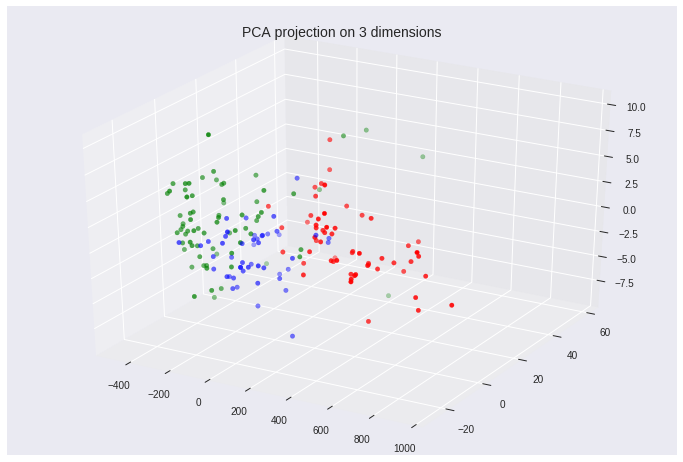

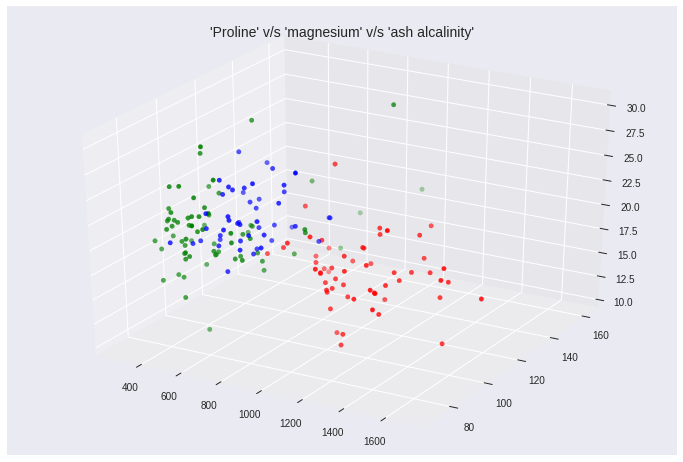

In [7]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

model = PCA(n_components=3)
model.fit(data)
data_3D = model.transform(data)

xx, xy, xz = data_3D.T
fig = plt.figure()
fig.set_figwidth(12)
fig.set_figheight(5.5/8*12)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xx, xy, xz, c=colors)
ax.set_title("PCA projection on 3 dimensions", fontdict={'size': 14});

fig = plt.figure()
fig.set_figwidth(12)
fig.set_figheight(5.5/8*12)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Proline'], data['magnesium'], data['ash alcalinity'], c=colors)
ax.set_title("'Proline' v/s 'magnesium' v/s 'ash alcalinity'", fontdict={'size': 14});

## Normalization effects in Dimensionality Reduction

When we think about the standard deviation of each variable of a raw data set, it is important to remember that these SDs are given *in the units of the variable*. This makes the SDs difficult to interpret. The SDs of the wine data set above illustrate this: Inspecting the SDs above, Proline has by far the greatest SD of $SD \approx 314$. This begs the question: 314 of what? also how does 314 compare to 14 of Magnesium?

This is where Normalization comes in. Let's see this in a 2D space.

---


Let's plot without and with normalization

In [0]:
def compute_and_plot_2d_pca(data, title):
  model = PCA(n_components=2)
  model.fit(data)
  data_2D = model.transform(data)

  xx, xy = data_2D.T
  plt.scatter(xx, xy, s=7, color=colors);
  plt.title(title)
  plt.xlabel('First Principal Component')
  plt.ylabel('Second Principal Component');

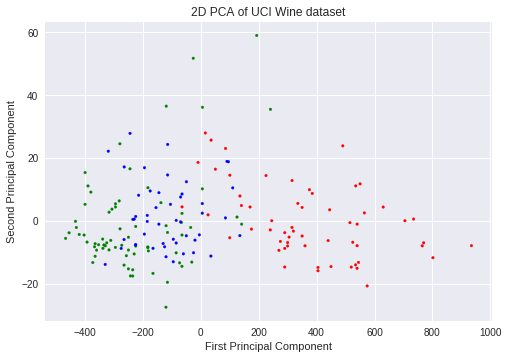

In [11]:
compute_and_plot_2d_pca(data, "2D PCA of UCI Wine dataset")

Normalize

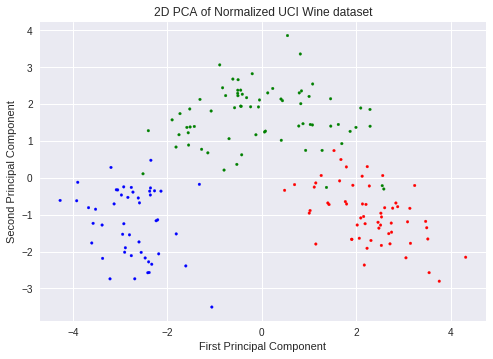

In [13]:
import sklearn.preprocessing as preprocessing

data_normalized = preprocessing.StandardScaler().fit_transform(data)
compute_and_plot_2d_pca(data_normalized, "2D PCA of Normalized UCI Wine dataset")

**Result:** Clearly separable Clusters!

## Care about the axis with Normalization

It's important to understand what Normalization is actually doing.

If you notice, we used `StandardScaler()` above to normalize. If we go to its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), it states **"Standardize features by removing the mean and scaling to unit variance"** - this is exactly what we wanted.


---


There is another very famous method in sklearn which is used for normalization - `normalize()`

Let's see what happens if we use that

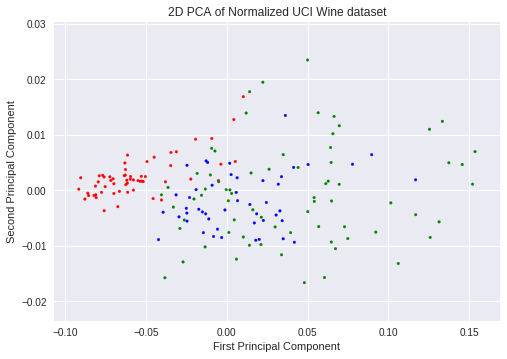

In [14]:
data_normalized = preprocessing.normalize(data)
compute_and_plot_2d_pca(data_normalized, "2D PCA of Normalized UCI Wine dataset")

**What happened above?**

Let's go to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html) again, it states **"Scale input vectors individually to unit norm"**

Input Vectors (i.e. Samples) v/s Features - that is the key difference.

Remember: we wanted to normalize the features so that their variance can be compared/used effectively by the PCA.

Now, if you notice carefully at the documentation of `normalize()` - you'll see there is an optional parameter called `axis`

![alt text](https://www.dropbox.com/s/yb6agh9yizmduvf/Screen%20Shot%202018-11-07%20at%205.34.23%20PM.png?raw=1)


What we needed to do was to provide `axis=0` to `normalize()` to normalize along the column/features

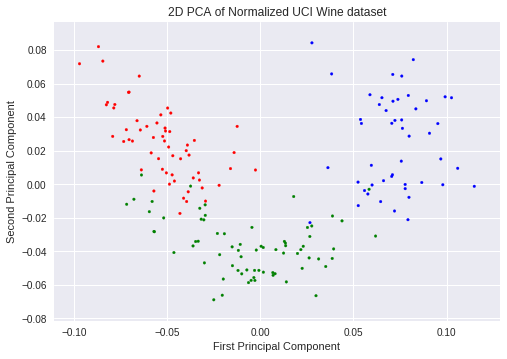

In [15]:
data_normalized = preprocessing.normalize(data, axis=0)
compute_and_plot_2d_pca(data_normalized, "2D PCA of Normalized UCI Wine dataset")

Clusters!